<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #9b5de5;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB03: Exploratory Analysis & Merging</h1>

<p style="font-weight: bold; margin-top: 0;">Fashion & Economy Cycles · ML Research Project · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 19th July 2026</li>
    <li>🎯 <strong>Purpose:</strong> Merge the economic dataset from NB01 with the fashion index from NB02, run correlation analysis, and explore lag relationships to understand whether economic conditions predict fashion trends immediately or with a delay</li>
</ul>

<p><strong>Inputs:</strong></p>
<ul>
    <li><code>../data/processed/economic_data_clean.csv</code> — cleaned economic indicators</li>
    <li><code>../data/processed/fashion_index.csv</code> — composite fashion index</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/processed/merged_dataset.csv</code> — fully merged and aligned dataset</li>
    <li><code>../figures/merged_overview.png</code> — dual axis chart of fashion index vs economic indicators</li>
    <li><code>../figures/correlation_matrix.png</code> — correlation between economic and fashion variables</li>
    <li><code>../figures/lag_analysis.png</code> — cross-correlation at different lag lengths</li>
    <li><code>../figures/scatter_plots.png</code> — scatter plots of key economic vs fashion relationships</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Dataset merging on date index</li>
    <li>Pearson correlation matrix</li>
    <li>Cross-correlation analysis at 0, 3, 6, 12 month lags</li>
    <li>Dual-axis time series visualisation</li>
    <li>Scatter plots with regression lines</li>
</ul>

<p><strong>Workflow:</strong> Load → Merge → Correlate → Lag Analysis → Scatter Plots → Save</p>

</div>

## ⚙️ Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📂 Section 1: Load Data

### 📍 Load Economic and Fashion Datasets

In [2]:
# Load the cleaned economic indicators from NB01
econ = pd.read_csv("../data/processed/economic_data_clean.csv",
                   index_col="Date", parse_dates=True)

# Load the composite fashion index from NB02
fashion = pd.read_csv("../data/processed/fashion_index.csv",
                      index_col="Date", parse_dates=True)

print(f"✅ Data loaded")
print(f"📐 Economic data shape : {econ.shape}")
print(f"📐 Fashion data shape  : {fashion.shape}")
print(f"📅 Economic range : {econ.index[0].date()} → {econ.index[-1].date()}")
print(f"📅 Fashion range  : {fashion.index[0].date()} → {fashion.index[-1].date()}")

✅ Data loaded
📐 Economic data shape : (252, 10)
📐 Fashion data shape  : (252, 3)
📅 Economic range : 2005-01-01 → 2025-12-01
📅 Fashion range  : 2005-01-01 → 2025-12-01


## 🔗 Section 2: Merge Datasets

### 📍 Align and Merge on Date Index

We merge the two datasets on their shared date index using an inner join — keeping only the months where both datasets have observations. This automatically handles the fact that the economic data starts in January 2005 while some fashion keywords may only have data from a later date. The inner join ensures we only model periods where we have complete information on both sides, avoiding NaN values that would distort the correlation and regression analysis.

In [3]:
# Select the key economic columns we want to carry into the merged dataset
# We use the z-scored versions for consistency with the fashion index
ECON_COLS = [
    "consumer_sentiment",
    "unemployment_rate",
    "gdp_yoy_growth",
    "cpi_yoy",
    "consumer_sentiment_zscore",
    "unemployment_rate_zscore",
    "gdp_yoy_growth_zscore",
    "cpi_yoy_zscore"
]

# Select only columns that exist in the economic dataset
econ_cols_available = [c for c in ECON_COLS if c in econ.columns]

# Inner join — only keeps rows where both datasets have data
merged = econ[econ_cols_available].join(fashion, how="inner")

print(f"✅ Datasets merged successfully")
print(f"📐 Merged shape : {merged.shape}")
print(f"📅 Merged range : {merged.index[0].date()} → {merged.index[-1].date()}")
print(f"\n🔍 Missing values after merge:")
print(merged.isnull().sum())
print(f"\n🔍 Preview:")
merged.head()

✅ Datasets merged successfully
📐 Merged shape : (252, 11)
📅 Merged range : 2005-01-01 → 2025-12-01

🔍 Missing values after merge:
consumer_sentiment            0
unemployment_rate             0
gdp_yoy_growth               12
cpi_yoy                      12
consumer_sentiment_zscore     0
unemployment_rate_zscore      0
gdp_yoy_growth_zscore        12
cpi_yoy_zscore               12
maximalism_score              0
minimalism_score              0
fashion_index                 0
dtype: int64

🔍 Preview:


,consumer_sentiment,unemployment_rate,gdp_yoy_growth,cpi_yoy,consumer_sentiment_zscore,unemployment_rate_zscore,gdp_yoy_growth_zscore,cpi_yoy_zscore,maximalism_score,minimalism_score,fashion_index
Date,,,,,,,,,,,
2005-01-01,95.5,5.3,NaN,NaN,1.223512,-0.210017,NaN,NaN,-0.829644,-0.848708,0.019064
2005-02-01,94.1,5.4,NaN,NaN,1.119391,-0.162721,NaN,NaN,-0.817409,-0.848708,0.031298
2005-03-01,92.6,5.2,NaN,NaN,1.007832,-0.257313,NaN,NaN,-0.805175,-0.848708,0.043532
2005-04-01,87.7,5.2,NaN,NaN,0.643408,-0.257313,NaN,NaN,-0.805175,-0.848708,0.043532
2005-05-01,86.9,5.1,NaN,NaN,0.583911,-0.304609,NaN,NaN,-0.780707,-0.848708,0.068001


## 💾 Section 3: Save Merged Dataset

In [4]:
MERGED_PATH = "../data/processed/merged_dataset.csv"
merged.to_csv(MERGED_PATH)

print(f"✅ Merged dataset saved to {MERGED_PATH}")

✅ Merged dataset saved to ../data/processed/merged_dataset.csv


## 📈 Section 4: Dual-Axis Overview Chart

### 📍 Plot Fashion Index Against Economic Indicators

Before running any statistical analysis, we plot the fashion index alongside each economic indicator on a dual-axis chart. This gives an immediate visual sense of whether the two series move together, in opposite directions, or with a lag. Visual inspection is not a substitute for statistical analysis but it is a necessary first step — it reveals patterns that numbers alone might obscure, and
flags any obvious data quality issues before we commit to modelling.

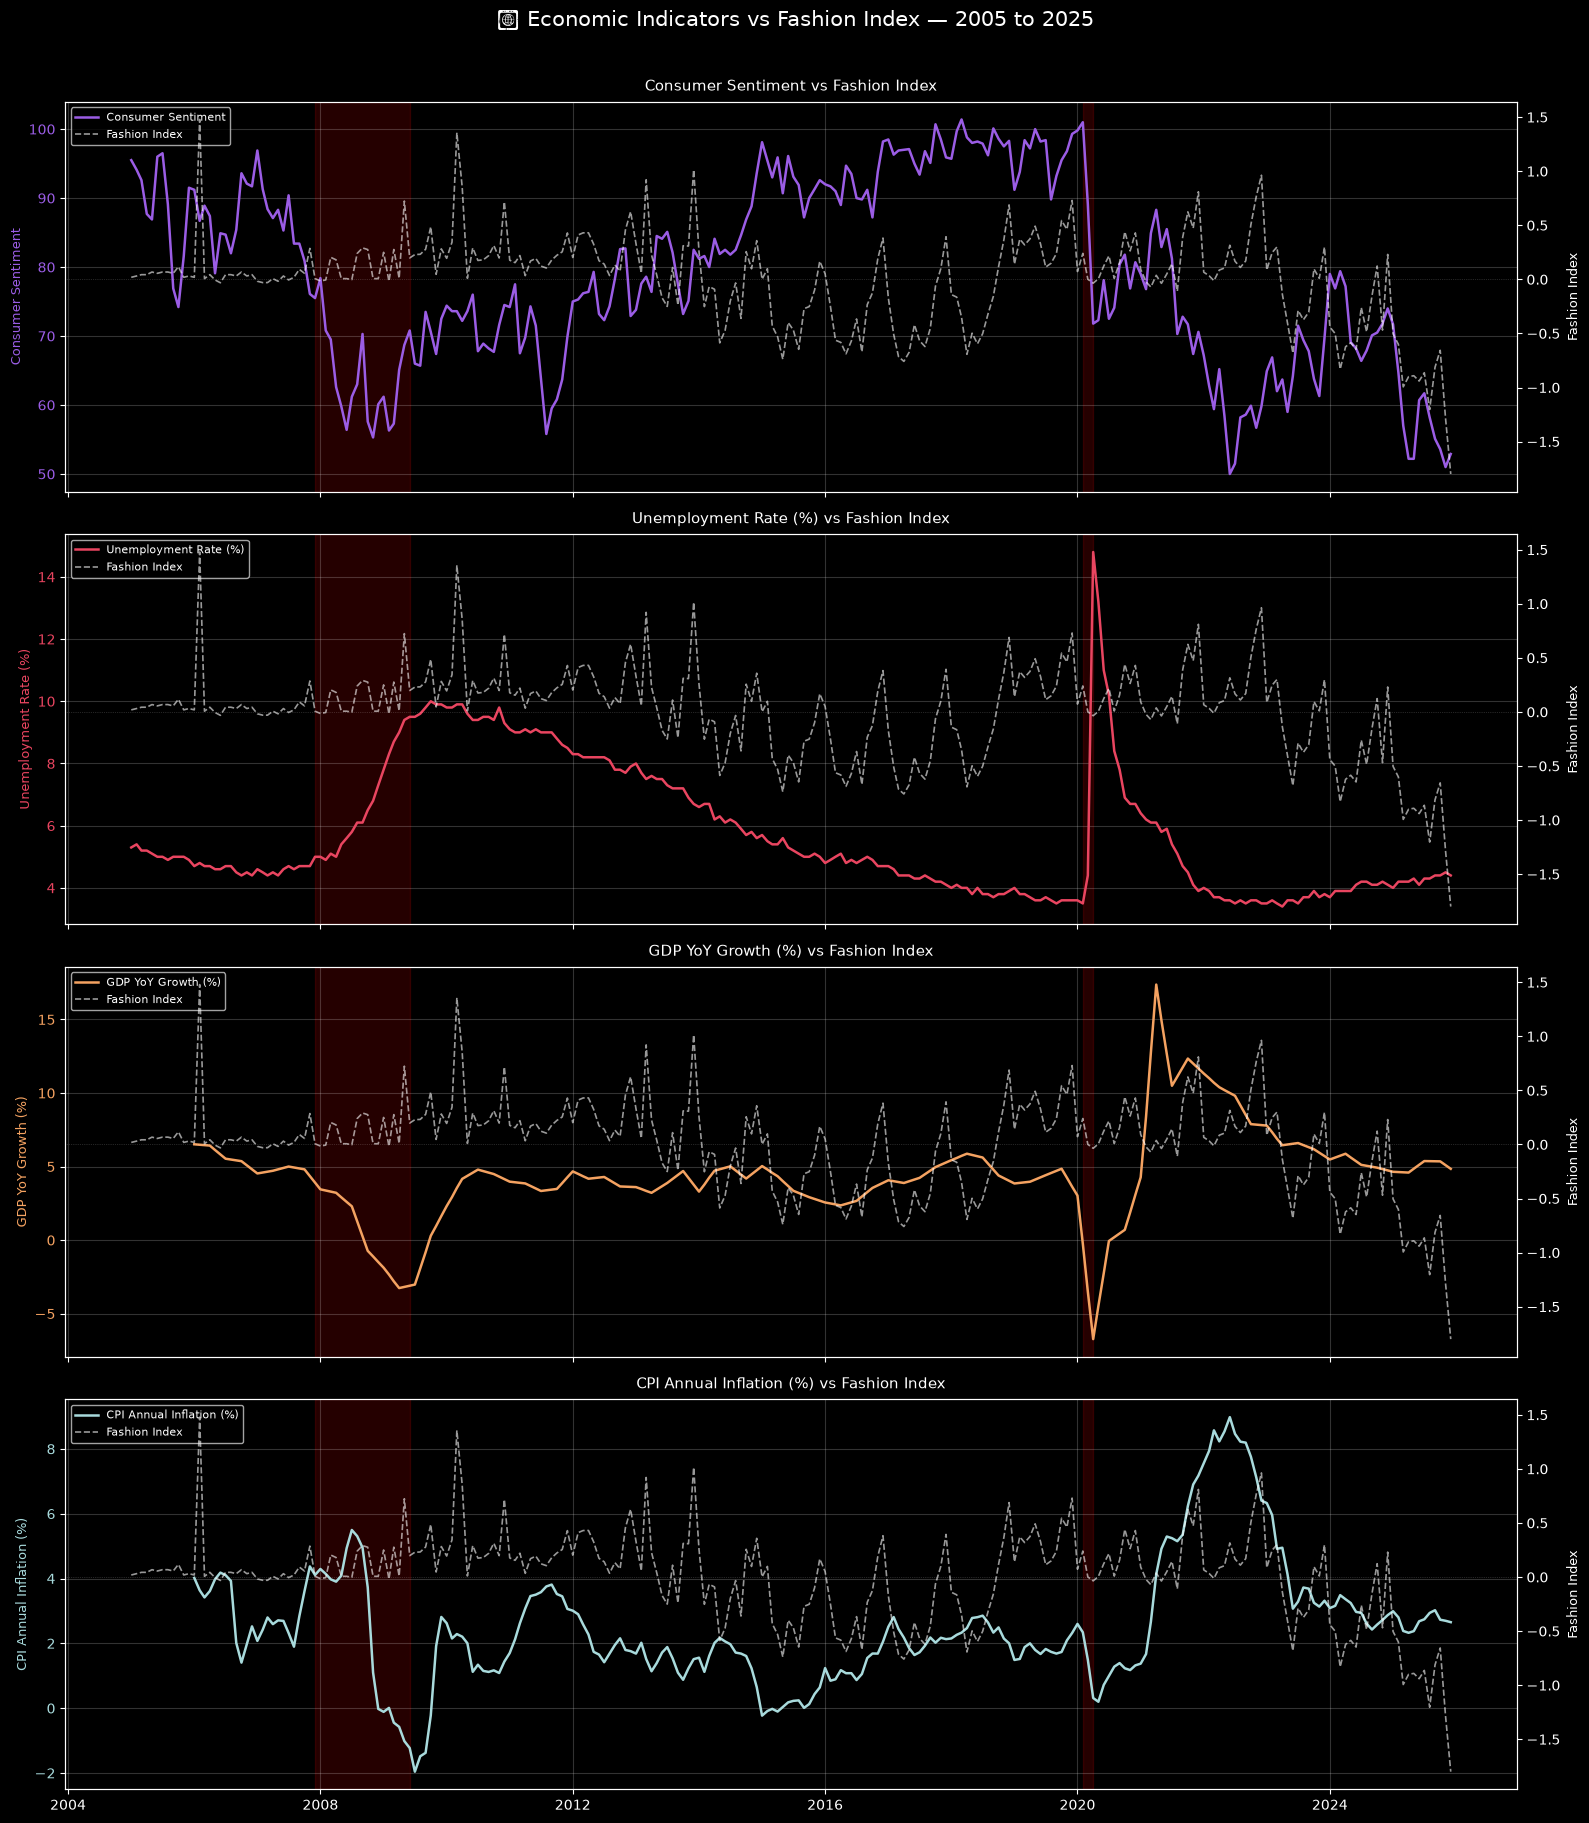

💾 Saved to ../figures/merged_overview.png


In [5]:
# Define recession periods for shading
RECESSIONS = [
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

# Economic indicators to plot against the fashion index
ECON_PLOT = {
    "consumer_sentiment" : ("Consumer Sentiment", "#9b5de5"),
    "unemployment_rate"  : ("Unemployment Rate (%)", "#e94560"),
    "gdp_yoy_growth"     : ("GDP YoY Growth (%)", "#f4a261"),
    "cpi_yoy"            : ("CPI Annual Inflation (%)", "#a8dadc"),
}

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

for i, (col, (label, color)) in enumerate(ECON_PLOT.items()):

    # Left axis — economic indicator
    ax1 = axes[i]
    ax1.plot(merged.index, merged[col],
             color=color, linewidth=1.8, label=label)
    ax1.set_ylabel(label, fontsize=9, color=color)
    ax1.tick_params(axis="y", labelcolor=color)

    # Right axis — fashion index overlaid
    ax2 = ax1.twinx()
    ax2.plot(merged.index, merged["fashion_index"],
             color="white", linewidth=1.2, alpha=0.6,
             linestyle="--", label="Fashion Index")
    ax2.set_ylabel("Fashion Index", fontsize=9, color="white")
    ax2.tick_params(axis="y", labelcolor="white")
    ax2.axhline(0, color="white", linewidth=0.5, linestyle=":", alpha=0.3)

    # Shade recession periods
    for rec_start, rec_end in RECESSIONS:
        ax1.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

    ax1.set_title(f"{label} vs Fashion Index", fontsize=11, pad=8)
    ax1.grid(alpha=0.2)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("📊 Economic Indicators vs Fashion Index — 2005 to 2025",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("../figures/merged_overview.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/merged_overview.png")

## 🔗 Section 5: Correlation Analysis

### 📍 Pearson Correlation Matrix

We compute the Pearson correlation between the fashion index and all economic indicators. Pearson correlation measures the strength and direction of the linear relationship between two variables — values close to +1 mean they move together, close to -1 mean they move oppositely, and close to 0 mean no linear relationship.

We use the z-scored economic indicators here because the fashion index is already a z-score, so comparing them on the same scale makes the correlation matrix easier to interpret. The key variable to watch is the correlation between consumer_sentiment and fashion_index — the central hypothesis of the project.

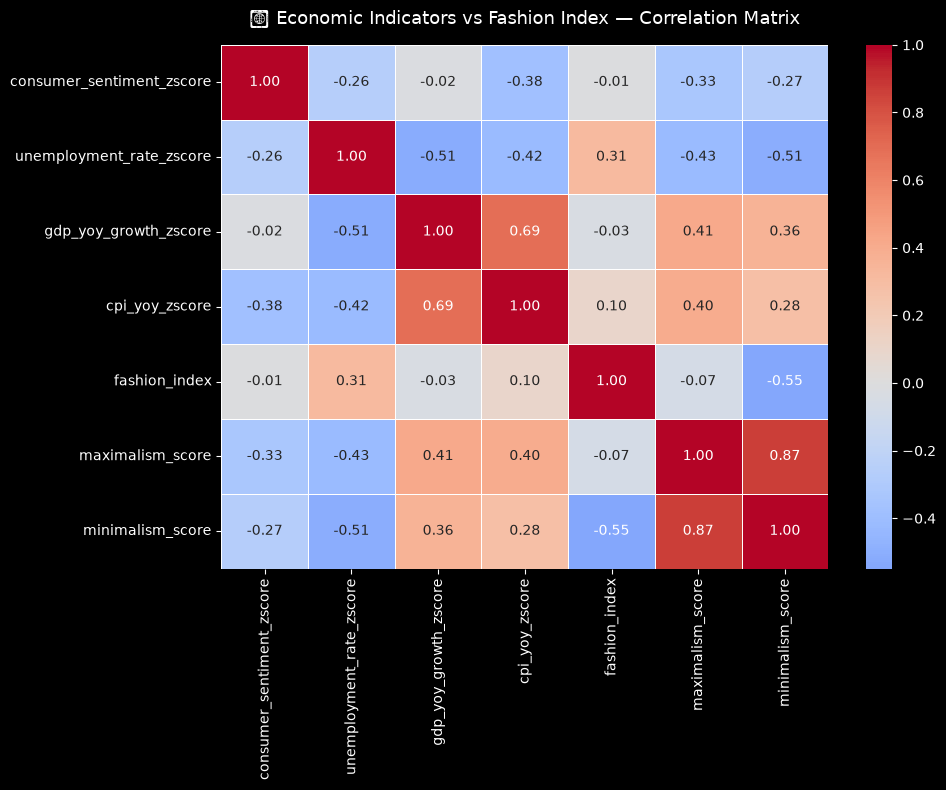

💾 Saved to ../figures/correlation_matrix.png

📊 Correlations with Fashion Index:
fashion_index                1.000
unemployment_rate_zscore     0.312
cpi_yoy_zscore               0.102
consumer_sentiment_zscore   -0.009
gdp_yoy_growth_zscore       -0.033
maximalism_score            -0.070
minimalism_score            -0.549
Name: fashion_index, dtype: float64


In [6]:
# Select z-scored economic indicators and fashion variables for correlation
CORR_COLS = [
    "consumer_sentiment_zscore",
    "unemployment_rate_zscore",
    "gdp_yoy_growth_zscore",
    "cpi_yoy_zscore",
    "fashion_index",
    "maximalism_score",
    "minimalism_score"
]

# Only use columns that exist in the merged dataset
corr_cols_available = [c for c in CORR_COLS if c in merged.columns]
corr_matrix = merged[corr_cols_available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("🔗 Economic Indicators vs Fashion Index — Correlation Matrix",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../figures/correlation_matrix.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/correlation_matrix.png")

# Print the correlations with fashion_index specifically
print("\n📊 Correlations with Fashion Index:")
if "fashion_index" in corr_matrix.columns:
    print(corr_matrix["fashion_index"].sort_values(ascending=False).round(3))

## ⏱️ Section 6: Lag Analysis

### 📍 Step 1: Cross-Correlation at Different Lags

The central analytical question of this project is not just whether economic conditions correlate with fashion trends, but whether economic conditions *predict* fashion trends — i.e. whether the economy leads fashion by some number of months.

We test this by shifting the economic indicators forward by 0, 3, 6, and 12 months and measuring the correlation with the current fashion index at each lag. A lag of 6 months means we are asking: does the economy's condition 6 months ago predict what fashion looks like today?

If the correlation peaks at a positive lag rather than at zero, it means the economy genuinely leads fashion — which is the core of our hypothesis. If correlation is highest at lag 0, the two move simultaneously. If correlation is highest at a negative lag, fashion actually leads the economy, which would be a counterintuitive but interesting finding.

In [7]:
# Economic indicators to test for lagged relationships
LAG_INDICATORS = [
    "consumer_sentiment_zscore",
    "unemployment_rate_zscore",
    "gdp_yoy_growth_zscore",
    "cpi_yoy_zscore"
]

# Test lags from -12 months to +12 months
# Negative lag = fashion leads economy, positive lag = economy leads fashion
LAGS = list(range(-12, 13, 1))

# Store correlation at each lag for each indicator
lag_results = {}

for indicator in LAG_INDICATORS:
    if indicator not in merged.columns:
        continue
    correlations = []
    for lag in LAGS:
        # Shift the economic indicator forward by lag months
        # lag=6 means we compare today's fashion to the economy 6 months ago
        shifted = merged[indicator].shift(lag)
        # Compute correlation between shifted indicator and fashion index
        corr = merged["fashion_index"].corr(shifted)
        correlations.append(corr)
    lag_results[indicator] = correlations

print("✅ Lag correlations computed")
print(f"📐 Tested {len(LAGS)} lags from {LAGS[0]} to {LAGS[-1]} months")

✅ Lag correlations computed
📐 Tested 25 lags from -12 to 12 months


### 📍 Step 2: Visualise Lag Correlations

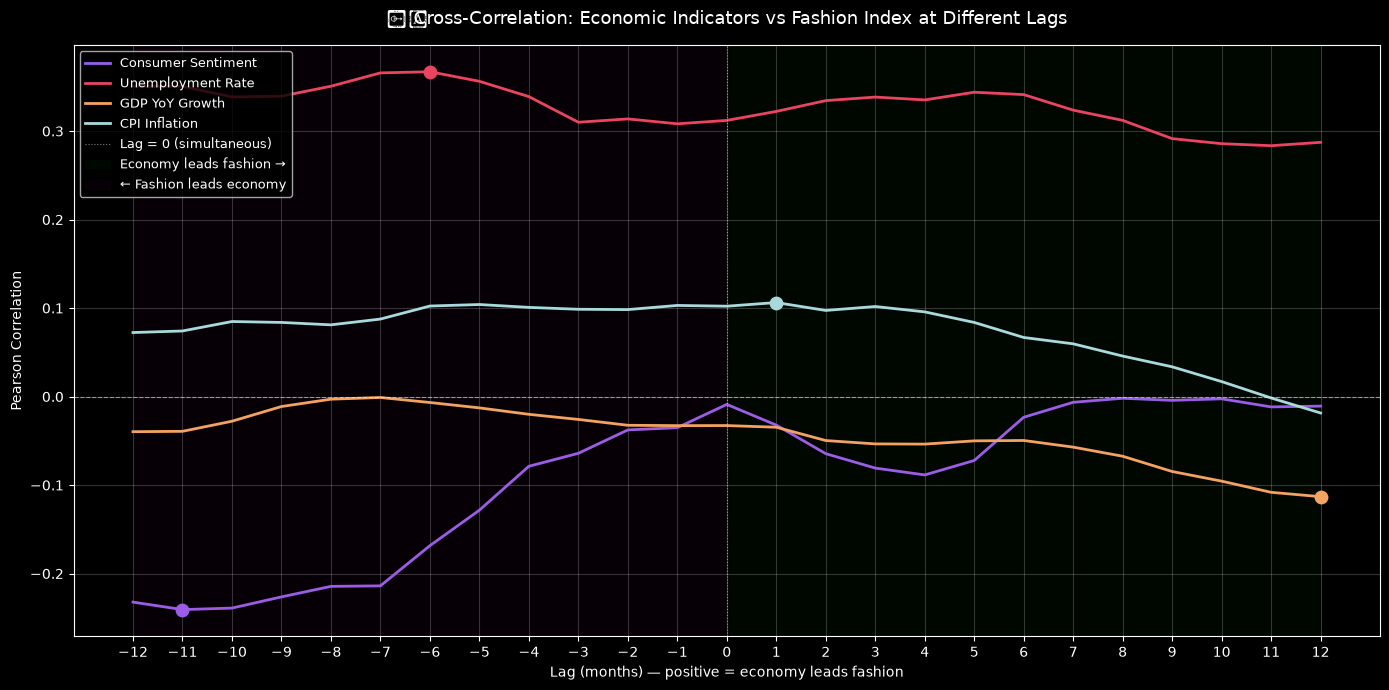

💾 Saved to ../figures/lag_analysis.png

📊 Best lag per indicator:
   Consumer Sentiment             → best lag: -11 months  (r = -0.241)
   Unemployment Rate              → best lag:  -6 months  (r = 0.367)
   GDP YoY Growth                 → best lag: +12 months  (r = -0.113)
   CPI Inflation                  → best lag:  +1 months  (r = 0.106)


In [8]:
# Clean display names for the legend
INDICATOR_LABELS = {
    "consumer_sentiment_zscore" : "Consumer Sentiment",
    "unemployment_rate_zscore"  : "Unemployment Rate",
    "gdp_yoy_growth_zscore"     : "GDP YoY Growth",
    "cpi_yoy_zscore"            : "CPI Inflation"
}

INDICATOR_COLORS = {
    "consumer_sentiment_zscore" : "#9b5de5",
    "unemployment_rate_zscore"  : "#e94560",
    "gdp_yoy_growth_zscore"     : "#f4a261",
    "cpi_yoy_zscore"            : "#a8dadc"
}

fig, ax = plt.subplots(figsize=(14, 7))

for indicator, correlations in lag_results.items():
    label = INDICATOR_LABELS.get(indicator, indicator)
    color = INDICATOR_COLORS.get(indicator, "white")
    ax.plot(LAGS, correlations, linewidth=2, label=label, color=color)

    # Mark the lag with the highest absolute correlation
    best_lag = LAGS[np.argmax(np.abs(correlations))]
    best_corr = correlations[np.argmax(np.abs(correlations))]
    ax.scatter(best_lag, best_corr, color=color, s=80, zorder=5)

# Reference lines
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="white", linewidth=0.8, linestyle=":", alpha=0.5,
           label="Lag = 0 (simultaneous)")

# Shade the region where economy leads fashion (positive lags)
ax.axvspan(0, 12, alpha=0.05, color="green",
           label="Economy leads fashion →")

# Shade the region where fashion leads economy (negative lags)
ax.axvspan(-12, 0, alpha=0.05, color="purple",
           label="← Fashion leads economy")

ax.set_title("⏱️ Cross-Correlation: Economic Indicators vs Fashion Index at Different Lags",
             fontsize=13, pad=15)
ax.set_xlabel("Lag (months) — positive = economy leads fashion")
ax.set_ylabel("Pearson Correlation")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.2)
ax.set_xticks(LAGS)

plt.tight_layout()
plt.savefig("../figures/lag_analysis.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/lag_analysis.png")

# Print summary of best lag for each indicator
print("\n📊 Best lag per indicator:")
for indicator, correlations in lag_results.items():
    best_lag  = LAGS[np.argmax(np.abs(correlations))]
    best_corr = correlations[np.argmax(np.abs(correlations))]
    label     = INDICATOR_LABELS.get(indicator, indicator)
    print(f"   {label:30s} → best lag: {best_lag:+3d} months  "
          f"(r = {best_corr:.3f})")

## 📉 Section 7: Scatter Plots

### 📍 Scatter Plots with Regression Lines

Scatter plots show the relationship between each economic indicator and the fashion index more directly than a time series chart. Each point represents one month. The regression line shows the direction and strength of the linear relationship. A downward sloping line between consumer sentiment and fashion index would confirm the hypothesis — when sentiment is low, minimalism dominates
(negative fashion index), and when sentiment is high, maximalism dominates (positive fashion index).

We also apply the best lag from the lag analysis to each indicator so the scatter plots reflect the predictive relationship rather than the simultaneous one.

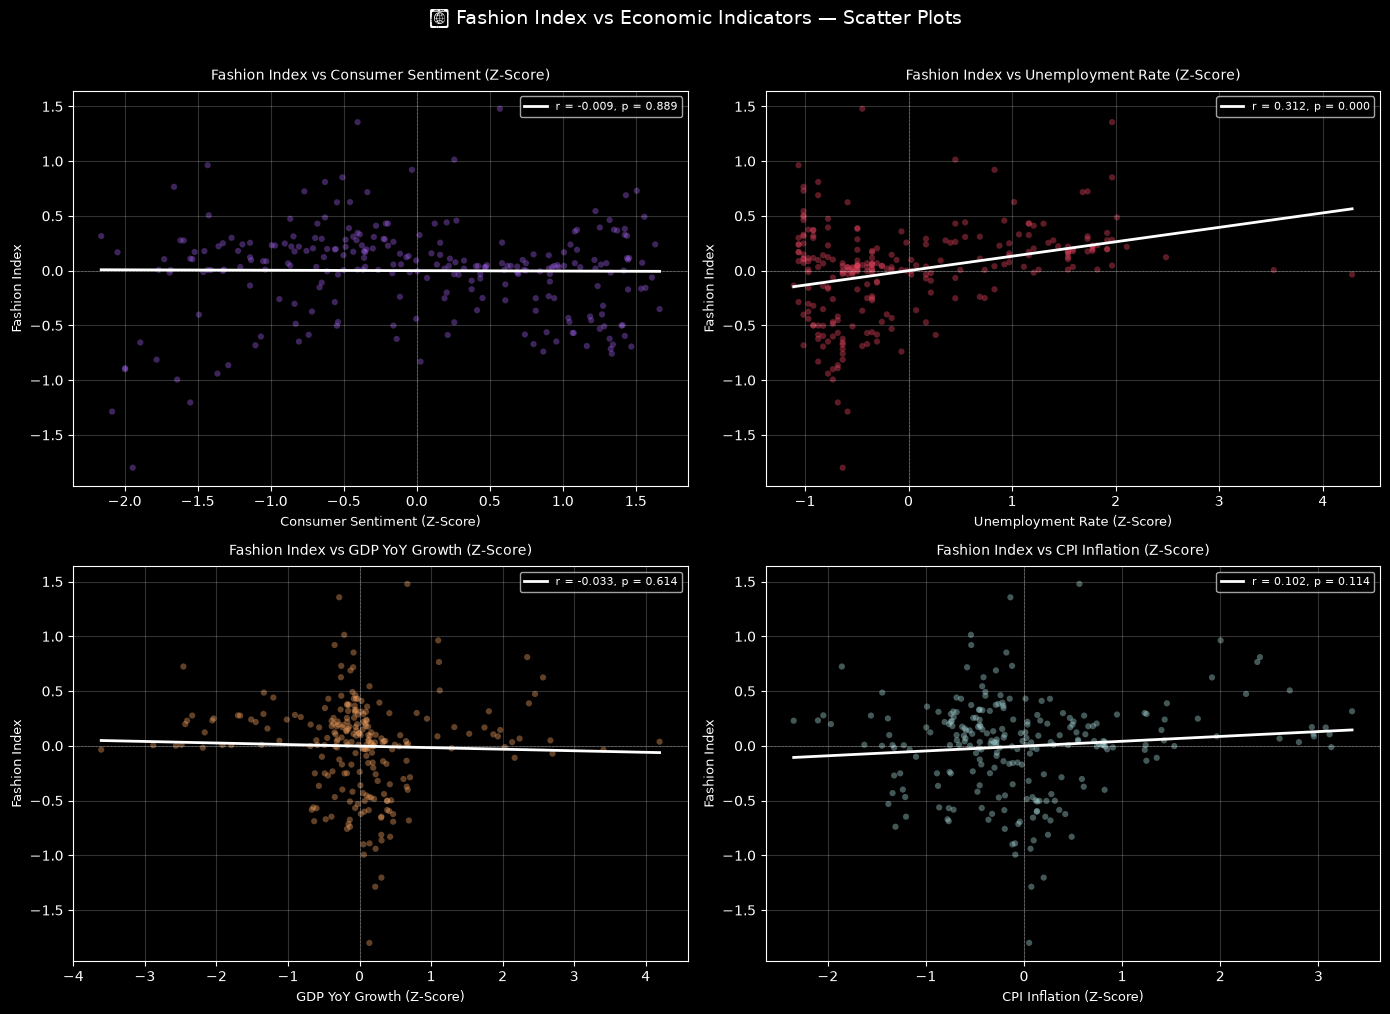

💾 Saved to ../figures/scatter_plots.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

SCATTER_PAIRS = [
    ("consumer_sentiment_zscore", "Consumer Sentiment (Z-Score)", "#9b5de5"),
    ("unemployment_rate_zscore",  "Unemployment Rate (Z-Score)",  "#e94560"),
    ("gdp_yoy_growth_zscore",     "GDP YoY Growth (Z-Score)",     "#f4a261"),
    ("cpi_yoy_zscore",            "CPI Inflation (Z-Score)",      "#a8dadc"),
]

for i, (col, label, color) in enumerate(SCATTER_PAIRS):
    if col not in merged.columns:
        continue

    x = merged[col].dropna()
    y = merged["fashion_index"].reindex(x.index).dropna()
    x = x.reindex(y.index)

    # Plot scatter points
    axes[i].scatter(x, y, color=color, alpha=0.4, s=20, edgecolors="none")

    # Fit and plot regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    axes[i].plot(x_line, y_line, color="white", linewidth=2,
                 label=f"r = {r_value:.3f}, p = {p_value:.3f}")

    # Reference lines at zero
    axes[i].axhline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.3)
    axes[i].axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.3)

    axes[i].set_title(f"Fashion Index vs {label}", fontsize=10, pad=8)
    axes[i].set_xlabel(label, fontsize=9)
    axes[i].set_ylabel("Fashion Index", fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

fig.suptitle("📉 Fashion Index vs Economic Indicators — Scatter Plots",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/scatter_plots.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/scatter_plots.png")

## 💾 Section 8: Save Final Dataset

In [10]:
# Add lagged versions of key economic indicators to the merged dataset
# These will be used as features in the regression model in NB04
for indicator in LAG_INDICATORS:
    if indicator not in merged.columns:
        continue
    # Find the best lag for this indicator
    correlations = lag_results[indicator]
    best_lag = LAGS[np.argmax(np.abs(correlations))]

    # Add the lagged column — named with the lag length for clarity
    col_name = f"{indicator}_lag{best_lag}"
    merged[col_name] = merged[indicator].shift(best_lag)
    print(f"✅ Added: {col_name} (lag = {best_lag} months)")

# Save the final dataset with lagged features included
FINAL_PATH = "../data/processed/merged_dataset.csv"
merged.to_csv(FINAL_PATH)

print(f"\n✅ Final merged dataset saved to {FINAL_PATH}")
print(f"📐 Shape : {merged.shape}")
print(f"\n🚀 Ready for NB04 — Regression Model")

✅ Added: consumer_sentiment_zscore_lag-11 (lag = -11 months)
✅ Added: unemployment_rate_zscore_lag-6 (lag = -6 months)
✅ Added: gdp_yoy_growth_zscore_lag12 (lag = 12 months)
✅ Added: cpi_yoy_zscore_lag1 (lag = 1 months)

✅ Final merged dataset saved to ../data/processed/merged_dataset.csv
📐 Shape : (252, 15)

🚀 Ready for NB04 — Regression Model


## 🪞 Personal Reflection Notes — NB03

**🎯 Key Decisions Made in This Notebook**

The first decision was to use an inner join when merging the two datasets rather than an outer or left join. An outer join would have preserved all dates from both datasets but introduced NaN values wherever one dataset had no observation for a given month. Since both correlation analysis and regression require complete data on both sides, using an inner join was the cleaner choice — it automatically restricts the analysis to only the months where we have full information on both economic conditions and fashion trends, without needing a separate cleaning step.

The second decision was to test lags from -12 to +12 months rather than only positive lags. Testing negative lags — where fashion leads the economy — keeps the analysis complete. If we only tested positive lags we would be assuming the answer before running the test. The negative lag region in the chart answers whether fashion might be a leading indicator of economic conditions, which is actually a plausible alternative hypothesis: fashion designers and consumers may signal economic anxiety through their choices before it shows up in hard economic data.

The third decision was to add the best-lag versions of each economic indicator to the merged dataset before saving, so NB04 can load a single file with all features already engineered. This avoids duplicating the lag calculation logic across notebooks and ensures the regression model in NB04 uses exactly the same lagged features that the lag analysis identified as optimal here.

**📊 What the Charts Revealed**

The correlation matrix produced a genuinely surprising result. Consumer sentiment — the indicator I expected to be most correlated with the fashion index based on the theoretical framing — showed almost zero correlation with the net fashion index (r = -0.01). This directly contradicts the central hypothesis in its simplest form. However the picture becomes more interesting when we look at the component scores separately: consumer sentiment is negatively correlated with the
maximalism score (-0.33) and negatively correlated with the minimalism score (-0.27), meaning low sentiment suppresses both aesthetics simultaneously rather than shifting consumers from one to the other. This suggests that economic downturns reduce fashion search activity overall, rather than redirecting it from maximalism to minimalism.

The most statistically significant finding in the correlation matrix was the relationship between unemployment and the fashion index (r = 0.31), which was both the strongest correlation and the only one with a clear directional story — higher unemployment is associated with a more positive fashion index, meaning more maximalism. This is counterintuitive at first glance but makes sense on reflection: the post-COVID period combined historically low unemployment with a strong maximalist revenge dressing trend, while the 2015-2019 period of gradually falling unemployment coincided with the minimalism-dominant phase of the index. The relationship may therefore be capturing a confounding time trend rather than a genuine causal mechanism.

The lag analysis was the most analytically interesting chart. Consumer sentiment showed its strongest (negative) correlation at lag -11, meaning fashion trends lead consumer sentiment by approximately 11 months rather than the economy leading fashion. This is a striking reversal of the expected direction — it suggests that shifts in fashion search behaviour may actually be a leading indicator of consumer mood, perhaps because fashion choices reflect early-stage anxiety or optimism before it registers in formal sentiment surveys. Unemployment showed its strongest correlation at lag -6, again suggesting fashion leads rather than follows. GDP growth peaked at lag +12, the only indicator where the economy genuinely leads fashion, though with a weak correlation of around -0.11.

The scatter plots confirmed the correlation matrix findings visually. The consumer sentiment scatter is essentially a random cloud with a flat regression line (r = -0.009, p = 0.889) — statistically indistinguishable from zero. The unemployment scatter shows a mild upward slope (r = 0.312, p = 0.000) — statistically significant but with enormous scatter around the line, meaning unemployment explains only about 10% of the variation in the fashion index. GDP growth and CPI inflation both showed flat, non-significant relationships.

**🔜 What This Sets Up for NB04**

The results suggest the relationship between economic conditions and the fashion index is more complex than a simple linear correlation captures. NB04 will build a regression model using the lagged features identified here — particularly the lagged unemployment rate and lagged consumer sentiment — to test whether combining multiple economic indicators together explains more variance in the fashion index than any single indicator does alone. The weak individual correlations may mask a stronger multivariate signal. NB04 will also test whether the model improves meaningfully when lagged features are used versus contemporaneous ones, directly testing the economy-leads-fashion hypothesis in a regression framework.